Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
train_std   : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]
TEMPERATURE : 0.8825289011001587
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images 

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,42,calibrated_msp,0.781417,0.952672,0.991354,347,1800


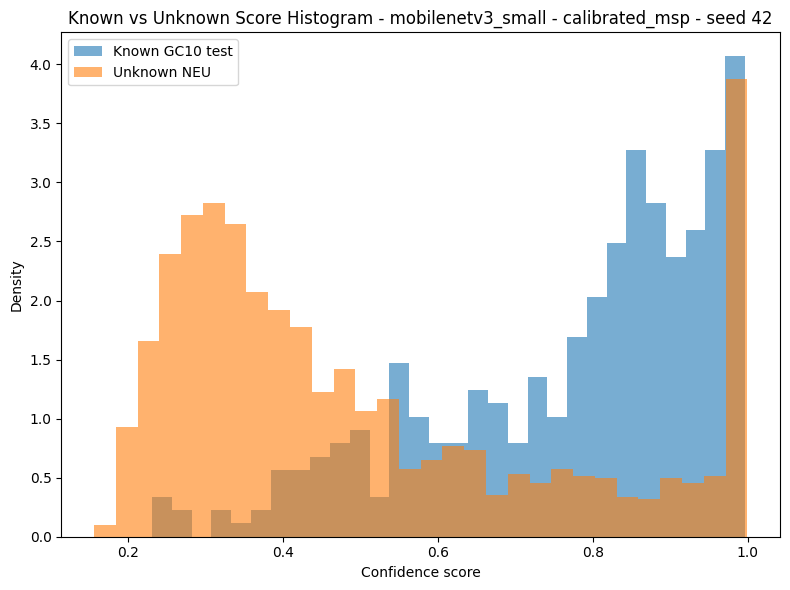

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,42,calibrated_msp,0.95,0.443598,0.936599,0.063401,0.873846,0.457222,0.542778
1,mobilenetv3_small,42,calibrated_msp,0.90,0.522295,0.878963,0.121037,0.901639,0.359444,0.640556
2,mobilenetv3_small,42,calibrated_msp,0.80,0.655192,0.752161,0.247839,0.950192,0.254444,0.745556


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.288690,-0.288690
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.296103,-0.296103
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.406155,-0.406155
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.313114,-0.313114
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.210392,-0.210392


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 42
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,42,calibrated_msp,0.781417,0.952672,0.991354,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,42,calibrated_msp,0.95,0.443598,0.936599,0.063401,0.873846,0.457222,0.542778
1,mobilenetv3_small,42,calibrated_msp,0.90,0.522295,0.878963,0.121037,0.901639,0.359444,0.640556
2,mobilenetv3_small,42,calibrated_msp,0.80,0.655192,0.752161,0.247839,0.950192,0.254444,0.745556


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
train_std   : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]
TEMPERATURE : 0.8548519015312195
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU imag

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,13,calibrated_msp,0.862099,0.964969,0.487032,347,1800


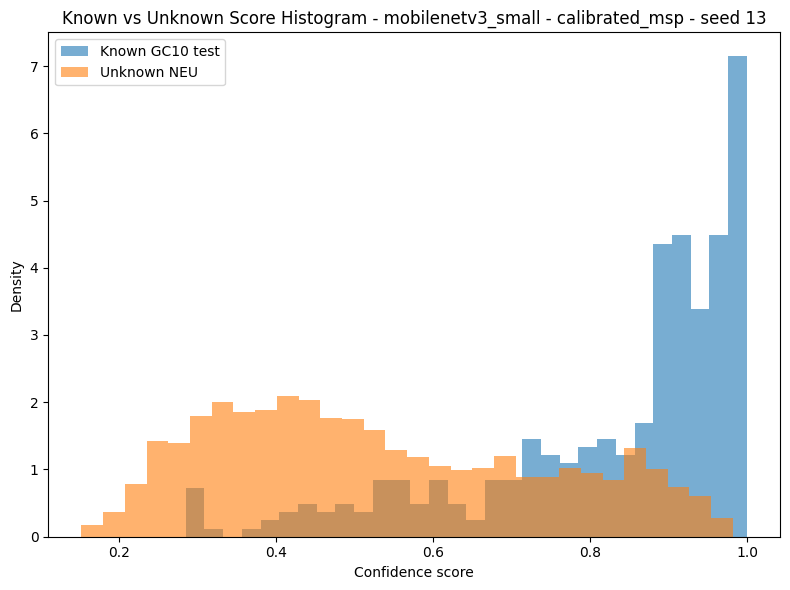

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,13,calibrated_msp,0.95,0.442288,0.951009,0.048991,0.909091,0.588333,0.411667
1,mobilenetv3_small,13,calibrated_msp,0.90,0.545273,0.902017,0.097983,0.916933,0.413889,0.586111
2,mobilenetv3_small,13,calibrated_msp,0.80,0.690512,0.812680,0.187320,0.950355,0.253889,0.746111


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.382647,-0.382647
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.434723,-0.434723
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.371739,-0.371739
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.570095,-0.570095
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.393235,-0.393235


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 13
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,13,calibrated_msp,0.862099,0.964969,0.487032,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,13,calibrated_msp,0.95,0.442288,0.951009,0.048991,0.909091,0.588333,0.411667
1,mobilenetv3_small,13,calibrated_msp,0.90,0.545273,0.902017,0.097983,0.916933,0.413889,0.586111
2,mobilenetv3_small,13,calibrated_msp,0.80,0.690512,0.812680,0.187320,0.950355,0.253889,0.746111


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
train_std   : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]
TEMPERATURE : 0.8230337500572205
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU imag

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,87,calibrated_msp,0.856817,0.966463,0.654179,347,1800


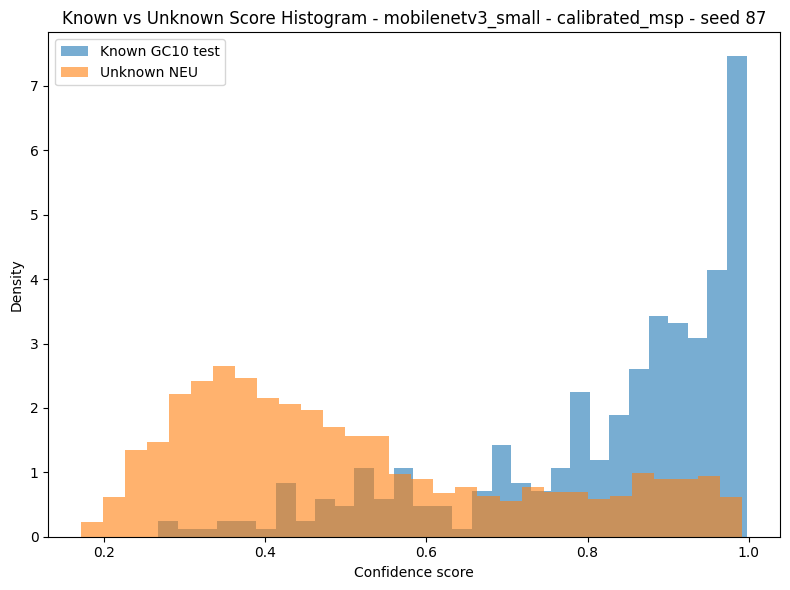

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,87,calibrated_msp,0.95,0.477373,0.936599,0.063401,0.876923,0.458333,0.541667
1,mobilenetv3_small,87,calibrated_msp,0.90,0.528022,0.902017,0.097983,0.894569,0.373889,0.626111
2,mobilenetv3_small,87,calibrated_msp,0.80,0.710166,0.775216,0.224784,0.929368,0.218333,0.781667


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.255422,-0.255422
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.402129,-0.402129
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.344966,-0.344966
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.385432,-0.385432
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.516398,-0.516398


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 87
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,87,calibrated_msp,0.856817,0.966463,0.654179,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,87,calibrated_msp,0.95,0.477373,0.936599,0.063401,0.876923,0.458333,0.541667
1,mobilenetv3_small,87,calibrated_msp,0.90,0.528022,0.902017,0.097983,0.894569,0.373889,0.626111
2,mobilenetv3_small,87,calibrated_msp,0.80,0.710166,0.775216,0.224784,0.929368,0.218333,0.781667


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [3]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
train_std   : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]
TEMPERATURE : 0.8230337500572205
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images foun

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,87,raw_msp,0.860889,0.967934,0.659942,347,1800


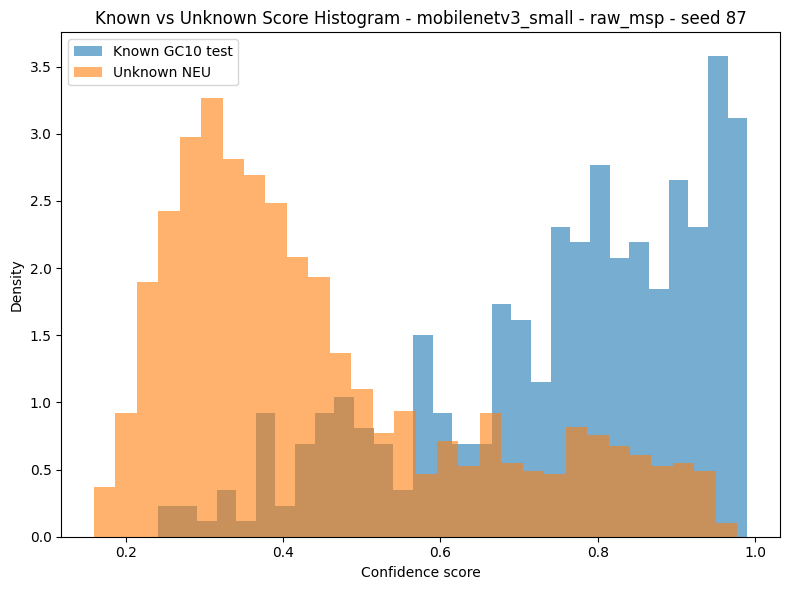

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,87,raw_msp,0.95,0.424423,0.942363,0.057637,0.880734,0.418333,0.581667
1,mobilenetv3_small,87,raw_msp,0.90,0.472323,0.893372,0.106628,0.893548,0.332778,0.667222
2,mobilenetv3_small,87,raw_msp,0.80,0.625258,0.763689,0.236311,0.932075,0.203333,0.796667


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.233349,-0.233349
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.353760,-0.353760
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.303068,-0.303068
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.328025,-0.328025
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.430101,-0.430101


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 87
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,87,raw_msp,0.860889,0.967934,0.659942,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,87,raw_msp,0.95,0.424423,0.942363,0.057637,0.880734,0.418333,0.581667
1,mobilenetv3_small,87,raw_msp,0.90,0.472323,0.893372,0.106628,0.893548,0.332778,0.667222
2,mobilenetv3_small,87,raw_msp,0.80,0.625258,0.763689,0.236311,0.932075,0.203333,0.796667


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [6]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
train_std   : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]
TEMPERATURE : 0.8825289011001587
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,42,raw_msp,0.783565,0.953436,0.991354,347,1800


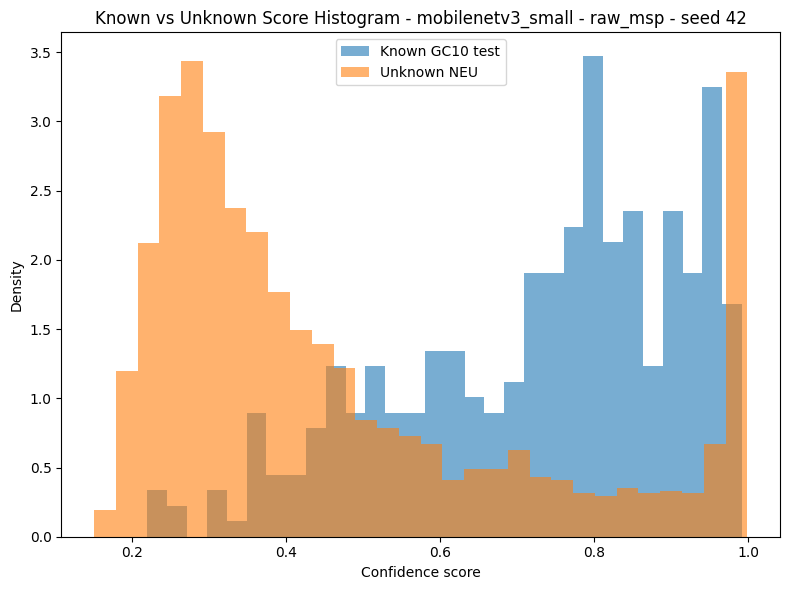

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,42,raw_msp,0.95,0.409087,0.930836,0.069164,0.876161,0.447778,0.552222
1,mobilenetv3_small,42,raw_msp,0.90,0.484871,0.873199,0.126801,0.900990,0.341111,0.658889
2,mobilenetv3_small,42,raw_msp,0.80,0.598521,0.752161,0.247839,0.946360,0.251667,0.748333


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.267411,-0.267411
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.275514,-0.275514
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.370048,-0.370048
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.287874,-0.287874
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.199755,-0.199755


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 42
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,42,raw_msp,0.783565,0.953436,0.991354,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,42,raw_msp,0.95,0.409087,0.930836,0.069164,0.876161,0.447778,0.552222
1,mobilenetv3_small,42,raw_msp,0.90,0.484871,0.873199,0.126801,0.900990,0.341111,0.658889
2,mobilenetv3_small,42,raw_msp,0.80,0.598521,0.752161,0.247839,0.946360,0.251667,0.748333


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [7]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
train_std   : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]
TEMPERATURE : 0.8548519015312195
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images foun

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,13,raw_msp,0.862967,0.96566,0.512968,347,1800


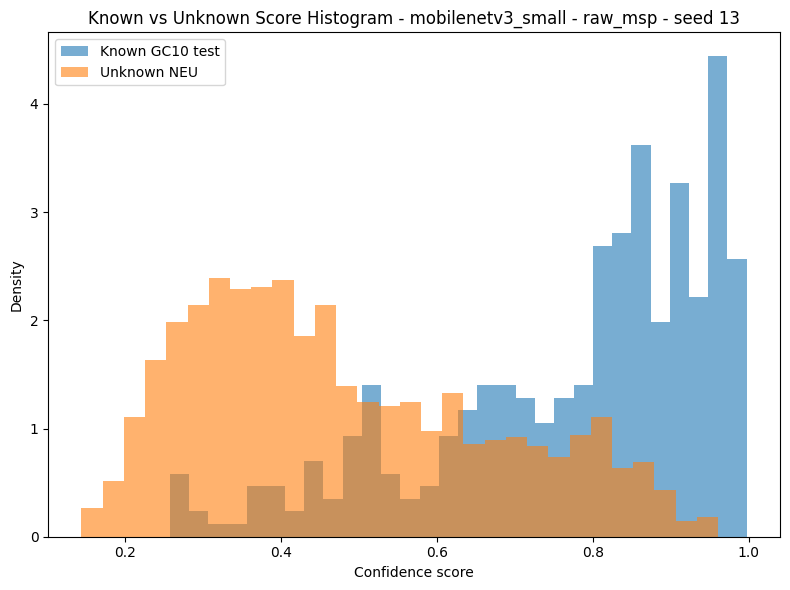

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,13,raw_msp,0.95,0.389004,0.956772,0.043228,0.903614,0.604444,0.395556
1,mobilenetv3_small,13,raw_msp,0.90,0.488188,0.913545,0.086455,0.914826,0.406667,0.593333
2,mobilenetv3_small,13,raw_msp,0.80,0.608601,0.827089,0.172911,0.944251,0.263333,0.736667


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.351473,-0.351473
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.389640,-0.389640
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.342867,-0.342867
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.504135,-0.504135
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.348169,-0.348169


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/threshold_rejection_table.json

MODEL     : mobilenetv3_small
SEED      : 13
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,mobilenetv3_small,13,raw_msp,0.862967,0.96566,0.512968,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,mobilenetv3_small,13,raw_msp,0.95,0.389004,0.956772,0.043228,0.903614,0.604444,0.395556
1,mobilenetv3_small,13,raw_msp,0.90,0.488188,0.913545,0.086455,0.914826,0.406667,0.593333
2,mobilenetv3_small,13,raw_msp,0.80,0.608601,0.827089,0.172911,0.944251,0.263333,0.736667


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [8]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
train_std   : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]
TEMPERATURE : 0.783771812915802
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths:
/mnt/e

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,87,raw_msp,0.959978,0.988695,0.138329,347,1800


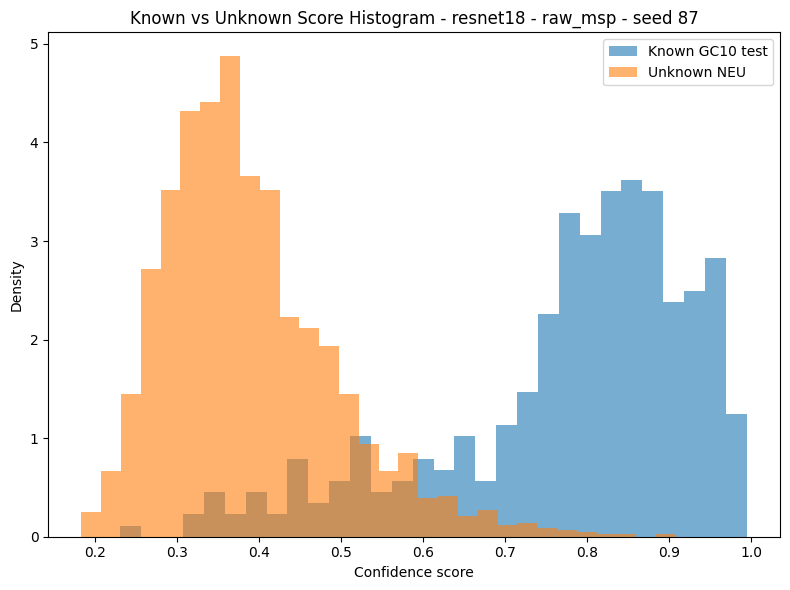

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,87,raw_msp,0.95,0.441983,0.951009,0.048991,0.915152,0.246667,0.753333
1,resnet18,87,raw_msp,0.90,0.509953,0.913545,0.086455,0.924290,0.118889,0.881111
2,resnet18,87,raw_msp,0.80,0.660713,0.801153,0.198847,0.942446,0.021111,0.978889


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.385531,-0.385531
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.332578,-0.332578
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.393712,-0.393712
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.347479,-0.347479
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.455366,-0.455366


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_raw_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 87
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,87,raw_msp,0.959978,0.988695,0.138329,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,87,raw_msp,0.95,0.441983,0.951009,0.048991,0.915152,0.246667,0.753333
1,resnet18,87,raw_msp,0.90,0.509953,0.913545,0.086455,0.924290,0.118889,0.881111
2,resnet18,87,raw_msp,0.80,0.660713,0.801153,0.198847,0.942446,0.021111,0.978889


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [9]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
train_std   : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]
TEMPERATURE : 0.8821859359741211
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths:
/mnt/e/C

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,42,raw_msp,0.531614,0.854517,0.976945,347,1800


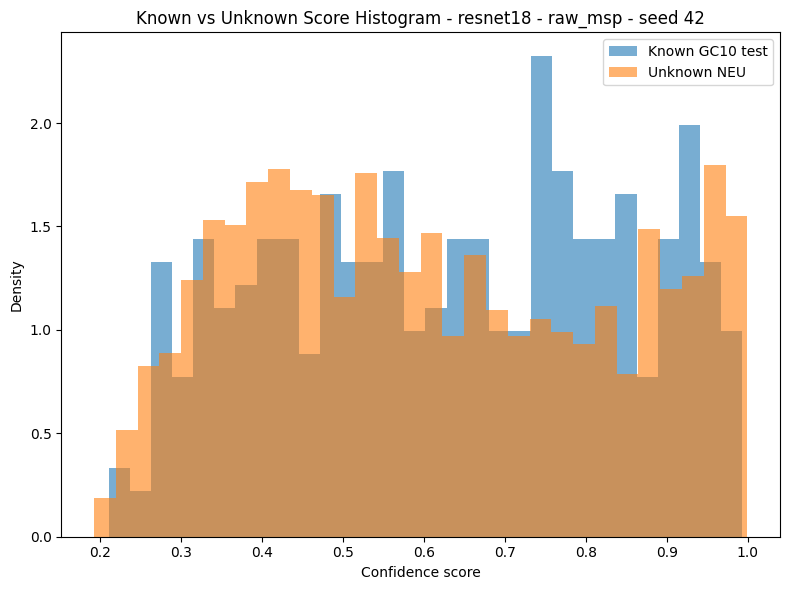

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,42,raw_msp,0.95,0.283636,0.956772,0.043228,0.765060,0.950556,0.049444
1,resnet18,42,raw_msp,0.90,0.345281,0.890490,0.109510,0.779935,0.875000,0.125000
2,resnet18,42,raw_msp,0.80,0.414990,0.798271,0.201729,0.801444,0.761111,0.238889


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.456752,-0.456752
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.608770,-0.608770
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.446046,-0.446046
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.443525,-0.443525
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.367383,-0.367383


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_raw_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 42
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,42,raw_msp,0.531614,0.854517,0.976945,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,42,raw_msp,0.95,0.283636,0.956772,0.043228,0.765060,0.950556,0.049444
1,resnet18,42,raw_msp,0.90,0.345281,0.890490,0.109510,0.779935,0.875000,0.125000
2,resnet18,42,raw_msp,0.80,0.414990,0.798271,0.201729,0.801444,0.761111,0.238889


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [10]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
train_std   : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]
TEMPERATURE : 0.8123471736907959
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths:
/mnt/

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,13,raw_msp,0.915623,0.979211,0.317003,347,1800


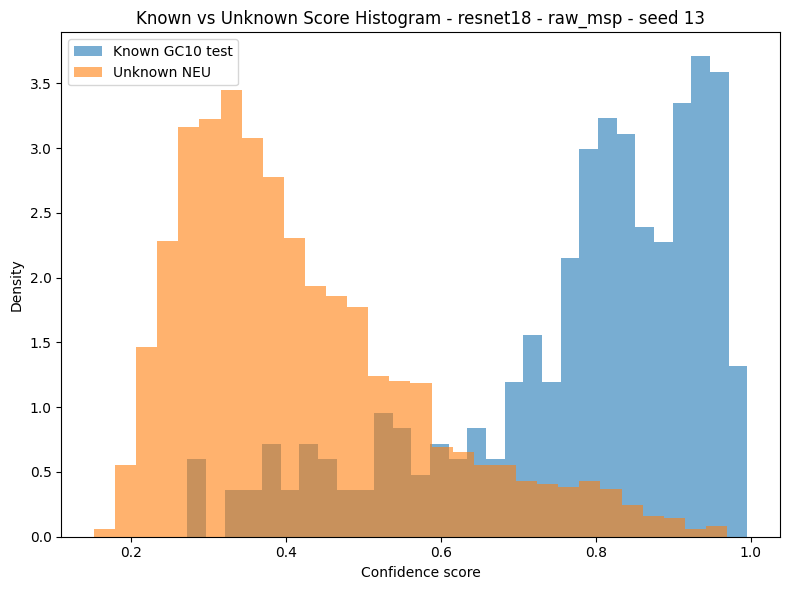

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,13,raw_msp,0.95,0.368258,0.968300,0.031700,0.904762,0.533333,0.466667
1,resnet18,13,raw_msp,0.90,0.480432,0.907781,0.092219,0.933333,0.283889,0.716111
2,resnet18,13,raw_msp,0.80,0.630271,0.806916,0.193084,0.964286,0.113333,0.886667


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.337227,-0.337227
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.433290,-0.433290
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.366130,-0.366130
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.290956,-0.290956
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.380662,-0.380662


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_raw_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 13
SCORE_NAME: raw_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,13,raw_msp,0.915623,0.979211,0.317003,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,13,raw_msp,0.95,0.368258,0.968300,0.031700,0.904762,0.533333,0.466667
1,resnet18,13,raw_msp,0.90,0.480432,0.907781,0.092219,0.933333,0.283889,0.716111
2,resnet18,13,raw_msp,0.80,0.630271,0.806916,0.193084,0.964286,0.113333,0.886667


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [11]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 / 13 / 87
SCORE_NAME = "raw_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
train_std   : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]
TEMPERATURE : 0.783771812915802
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths:

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,87,calibrated_msp,0.95788,0.988317,0.149856,347,1800


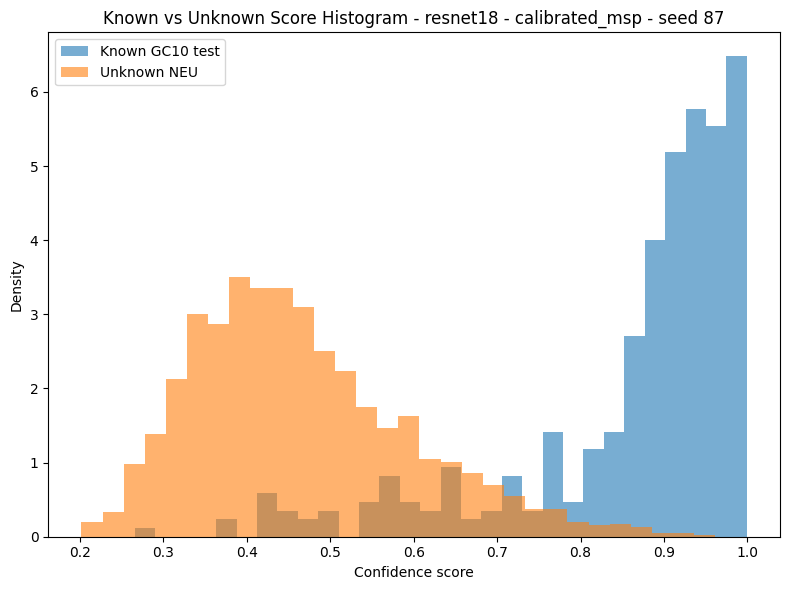

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,87,calibrated_msp,0.95,0.525768,0.953890,0.046110,0.915408,0.270556,0.729444
1,resnet18,87,calibrated_msp,0.90,0.608996,0.910663,0.089337,0.924051,0.143333,0.856667
2,resnet18,87,calibrated_msp,0.80,0.785481,0.798271,0.201729,0.945848,0.019444,0.980556


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.482918,-0.482918
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.402358,-0.402358
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.463736,-0.463736
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.412639,-0.412639
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.562632,-0.562632


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87__score_calibrated_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 87
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,87,calibrated_msp,0.95788,0.988317,0.149856,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,87,calibrated_msp,0.95,0.525768,0.953890,0.046110,0.915408,0.270556,0.729444
1,resnet18,87,calibrated_msp,0.90,0.608996,0.910663,0.089337,0.924051,0.143333,0.856667
2,resnet18,87,calibrated_msp,0.80,0.785481,0.798271,0.201729,0.945848,0.019444,0.980556


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [12]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 87                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
train_std   : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]
TEMPERATURE : 0.8821859359741211
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths:
/

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,42,calibrated_msp,0.537129,0.855898,0.974063,347,1800


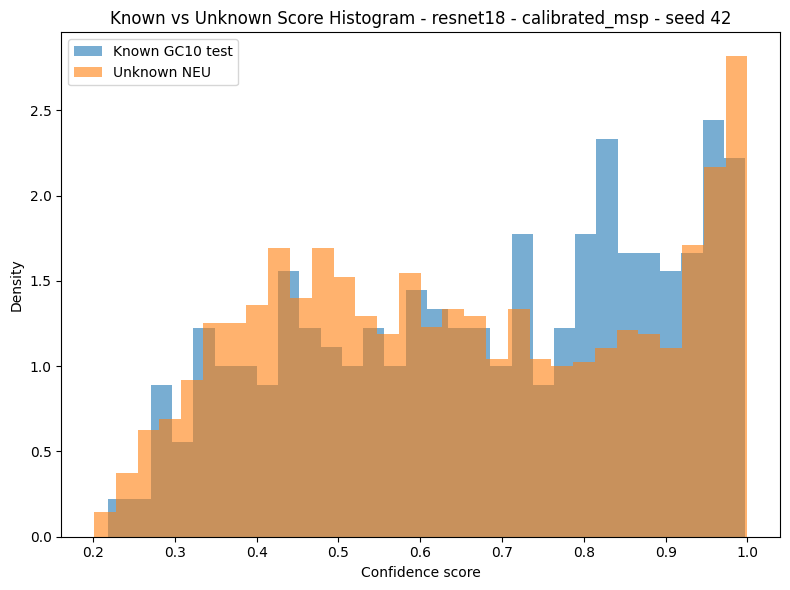

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,42,calibrated_msp,0.95,0.306408,0.959654,0.040346,0.762763,0.951667,0.048333
1,resnet18,42,calibrated_msp,0.90,0.372248,0.893372,0.106628,0.780645,0.880000,0.120000
2,resnet18,42,calibrated_msp,0.80,0.449635,0.812680,0.187320,0.808511,0.765000,0.235000


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.486478,-0.486478
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.663862,-0.663862
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.484493,-0.484493
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.467974,-0.467974
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.391921,-0.391921


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42__score_calibrated_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 42
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,42,calibrated_msp,0.537129,0.855898,0.974063,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,42,calibrated_msp,0.95,0.306408,0.959654,0.040346,0.762763,0.951667,0.048333
1,resnet18,42,calibrated_msp,0.90,0.372248,0.893372,0.106628,0.780645,0.880000,0.120000
2,resnet18,42,calibrated_msp,0.80,0.449635,0.812680,0.187320,0.808511,0.765000,0.235000


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [13]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 42                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


Imports loaded successfully.
PROJECT_ROOT : /mnt/e/CVPR/steel_failure_aware
RAW_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
CAL_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/calibration/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13
OUT_RUN_DIR  : /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp
NEU_DIR      : /mnt/e/CVPR/NEU
CONFIG_JSON  : True
BEST_MODEL   : True
TEST_PRED_CSV: True
VAL_PRED_CSV : True
TEMP_JSON    : True
IMAGE_SIZE  : 224
train_mean  : [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
train_std   : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]
TEMPERATURE : 0.8123471736907959
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Model loaded successfully.
Transform ready.
Total NEU images found: 1800
Sample paths

,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,13,calibrated_msp,0.914299,0.978441,0.302594,347,1800


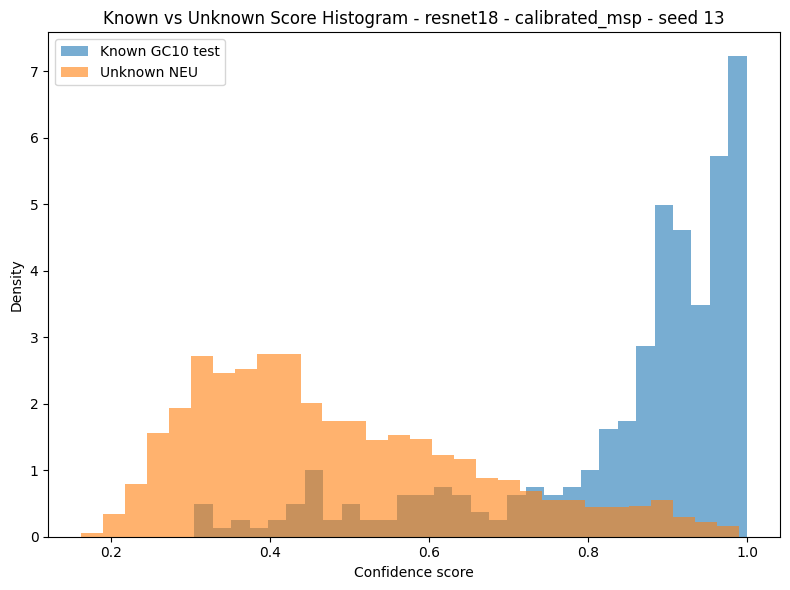

,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,13,calibrated_msp,0.95,0.420936,0.971182,0.028818,0.902077,0.553889,0.446111
1,resnet18,13,calibrated_msp,0.90,0.554344,0.910663,0.089337,0.930380,0.306667,0.693333
2,resnet18,13,calibrated_msp,0.80,0.733279,0.809798,0.190202,0.964413,0.106667,0.893333


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/neu_scores.csv


,filepath,confidence_score,anomaly_score
0,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.382902,-0.382902
1,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.509220,-0.509220
2,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.424244,-0.424244
3,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.324204,-0.324204
4,/mnt/e/CVPR/NEU/train/images/crazing/crazing_1...,0.440865,-0.440865


Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/ood_metrics.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/ood_metrics.json
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/threshold_rejection_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13__score_calibrated_msp/threshold_rejection_table.json

MODEL     : resnet18
SEED      : 13
SCORE_NAME: calibrated_msp

OOD metrics


,model,seed,score_name,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown_neu
0,resnet18,13,calibrated_msp,0.914299,0.978441,0.302594,347,1800



Threshold-based rejection table


,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_reject_rate_test,known_accuracy_after_reject,unknown_accept_rate_neu,unknown_reject_rate_neu
0,resnet18,13,calibrated_msp,0.95,0.420936,0.971182,0.028818,0.902077,0.553889,0.446111
1,resnet18,13,calibrated_msp,0.90,0.554344,0.910663,0.089337,0.930380,0.306667,0.693333
2,resnet18,13,calibrated_msp,0.80,0.733279,0.809798,0.190202,0.964413,0.106667,0.893333


Saved files:
- known_vs_unknown_score_histogram.png
- neu_scores.csv
- ood_metrics.csv
- ood_metrics.json
- threshold_rejection_table.csv
- threshold_rejection_table.json


In [14]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")
from pathlib import Path

# =========================
# CONFIG
# =========================
MODEL_NAME = "resnet18"   # "mobilenetv3_small" or "resnet18"
SEED = 13                          # 42 / 13 / 87
SCORE_NAME = "calibrated_msp"      # "calibrated_msp" or "raw_msp"

OPTIMIZER_NAME = "adamw"	
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
USE_PRETRAINED = True

NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"

CLOSED_SET_DIR = PROJECT_ROOT / "runs" / "closed_set"
CALIBRATION_DIR = PROJECT_ROOT / "runs" / "calibration"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RAW_RUN_DIR = CLOSED_SET_DIR / RUN_NAME
CAL_RUN_DIR = CALIBRATION_DIR / RUN_NAME
OUT_RUN_DIR = EXTERNAL_DIR / f"{RUN_NAME}__score_{SCORE_NAME}"
OUT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = RAW_RUN_DIR / "config.json"
BEST_MODEL_PTH = RAW_RUN_DIR / "best_model.pth"
TEST_PRED_CSV = RAW_RUN_DIR / "test_predictions.csv"
VAL_PRED_CSV = RAW_RUN_DIR / "val_predictions.csv"
TEMP_JSON = CAL_RUN_DIR / "temperature.json"

# User’s shown NEU structure
NEU_DIR_CANDIDATES = [
    BASE_DIR / "NEU",
    PROJECT_ROOT / "data" / "raw" / "NEU",
]

NEU_DIR = None
for p in NEU_DIR_CANDIDATES:
    if p.exists():
        NEU_DIR = p
        break

if NEU_DIR is None:
    raise FileNotFoundError("Could not find NEU folder.")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_RUN_DIR  :", RAW_RUN_DIR)
print("CAL_RUN_DIR  :", CAL_RUN_DIR)
print("OUT_RUN_DIR  :", OUT_RUN_DIR)
print("NEU_DIR      :", NEU_DIR)
print("CONFIG_JSON  :", CONFIG_JSON.exists())
print("BEST_MODEL   :", BEST_MODEL_PTH.exists())
print("TEST_PRED_CSV:", TEST_PRED_CSV.exists())
print("VAL_PRED_CSV :", VAL_PRED_CSV.exists())
print("TEMP_JSON    :", TEMP_JSON.exists())
with open(CONFIG_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

IMAGE_SIZE = int(cfg["image_size"])
train_mean = cfg["train_mean"]
train_std = cfg["train_std"]

with open(TEMP_JSON, "r", encoding="utf-8") as f:
    temp_dict = json.load(f)

TEMPERATURE = float(temp_dict["temperature"])

print("IMAGE_SIZE  :", IMAGE_SIZE)
print("train_mean  :", train_mean)
print("train_std   :", train_std)
print("TEMPERATURE :", TEMPERATURE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


if MODEL_NAME == "mobilenetv3_small":
    model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
elif MODEL_NAME == "resnet18":
    model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED)
else:
    raise ValueError("Unsupported MODEL_NAME")

model.load_state_dict(torch.load(BEST_MODEL_PTH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

print("Transform ready.")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

neu_paths = []
for split_name in ["train", "validation", "val", "test"]:
    split_dir = NEU_DIR / split_name
    if split_dir.exists():
        for p in split_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                neu_paths.append(str(p))

# Fallback: collect all recursive images if train/validation folders are not enough
if len(neu_paths) == 0:
    for p in NEU_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            neu_paths.append(str(p))

neu_paths = sorted(list(set(neu_paths)))

print("Total NEU images found:", len(neu_paths))
print("Sample paths:")
for p in neu_paths[:5]:
    print(p)
class UnknownImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, img_path

neu_ds = UnknownImageDataset(neu_paths, eval_transform)
neu_loader = DataLoader(
    neu_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("NEU batches:", len(neu_loader))
def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def normalized_entropy(probs, eps=1e-12):
    ent = -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=1)
    ent = ent / np.log(probs.shape[1])
    return ent

def confidence_from_probs_and_logits(probs, logits, score_name):
    if score_name == "raw_msp":
        return np.max(probs, axis=1)
    elif score_name == "calibrated_msp":
        return np.max(probs, axis=1)
    else:
        raise ValueError("For this notebook use only raw_msp or calibrated_msp")

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    # positive class = unknown = 1
    fpr, tpr, thresholds = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

val_df = pd.read_csv(VAL_PRED_CSV)
test_df = pd.read_csv(TEST_PRED_CSV)

raw_prob_cols = sorted([c for c in test_df.columns if c.startswith("prob_class_")], key=lambda x: int(x.split("_")[-1]))
raw_logit_cols = sorted([c for c in test_df.columns if c.startswith("logit_class_")], key=lambda x: int(x.split("_")[-1]))

val_probs_raw = val_df[raw_prob_cols].values.astype(np.float32)
val_logits_raw = val_df[raw_logit_cols].values.astype(np.float32)

test_probs_raw = test_df[raw_prob_cols].values.astype(np.float32)
test_logits_raw = test_df[raw_logit_cols].values.astype(np.float32)

# Calibrated versions via saved temperature
val_logits_cal = val_logits_raw / TEMPERATURE
test_logits_cal = test_logits_raw / TEMPERATURE

val_probs_cal = softmax_numpy(val_logits_cal)
test_probs_cal = softmax_numpy(test_logits_cal)

y_test_true = test_df["y_true"].values.astype(np.int64)
y_test_pred = test_df["y_pred"].values.astype(np.int64)

print("Known validation/test predictions loaded.")
print("val:", val_probs_raw.shape, val_logits_raw.shape)
print("test:", test_probs_raw.shape, test_logits_raw.shape)

@torch.no_grad()
def infer_unknown_logits(model, loader, device):
    all_logits = []
    all_paths = []

    for images, paths in loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu().numpy())
        all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, all_paths

neu_logits_raw, neu_paths_out = infer_unknown_logits(model, neu_loader, DEVICE)
neu_probs_raw = softmax_numpy(neu_logits_raw)

neu_logits_cal = neu_logits_raw / TEMPERATURE
neu_probs_cal = softmax_numpy(neu_logits_cal)

print("NEU inference done.")
print("neu_logits_raw:", neu_logits_raw.shape)

if SCORE_NAME == "raw_msp":
    known_val_conf = np.max(val_probs_raw, axis=1)
    known_test_conf = np.max(test_probs_raw, axis=1)
    unknown_conf = np.max(neu_probs_raw, axis=1)
elif SCORE_NAME == "calibrated_msp":
    known_val_conf = np.max(val_probs_cal, axis=1)
    known_test_conf = np.max(test_probs_cal, axis=1)
    unknown_conf = np.max(neu_probs_cal, axis=1)
else:
    raise ValueError("Use SCORE_NAME = 'raw_msp' or 'calibrated_msp'")

print("Known val conf range :", float(known_val_conf.min()), float(known_val_conf.max()))
print("Known test conf range:", float(known_test_conf.min()), float(known_test_conf.max()))
print("Unknown conf range   :", float(unknown_conf.min()), float(unknown_conf.max()))

known_scores = known_test_conf
unknown_scores = unknown_conf

y_binary = np.concatenate([
    np.zeros(len(known_scores), dtype=np.int64),   # known = 0
    np.ones(len(unknown_scores), dtype=np.int64),  # unknown = 1
])

anomaly_scores = np.concatenate([
    -known_scores,
    -unknown_scores,
])

auroc = roc_auc_score(y_binary, anomaly_scores)
aupr = average_precision_score(y_binary, anomaly_scores)
fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

ood_metrics = pd.DataFrame([{
    "model": MODEL_NAME,
    "seed": SEED,
    "score_name": SCORE_NAME,
    "auroc_unknown_positive": float(auroc),
    "aupr_unknown_positive": float(aupr),
    "fpr_at_95_tpr": float(fpr95),
    "n_known_test": int(len(known_scores)),
    "n_unknown_neu": int(len(unknown_scores)),
}])

display(ood_metrics)
plt.figure(figsize=(8, 6))
plt.hist(known_scores, bins=30, alpha=0.6, label="Known GC10 test", density=True)
plt.hist(unknown_scores, bins=30, alpha=0.6, label="Unknown NEU", density=True)
plt.xlabel("Confidence score")
plt.ylabel("Density")
plt.title(f"Known vs Unknown Score Histogram - {MODEL_NAME} - {SCORE_NAME} - seed {SEED}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_RUN_DIR / "known_vs_unknown_score_histogram.png", dpi=200)
plt.show()
threshold_rows = []

for cov in THRESHOLD_COVERAGES:
    threshold = float(np.quantile(known_val_conf, 1.0 - cov))

    known_accept = known_test_conf >= threshold
    unknown_accept = unknown_conf >= threshold

    known_accept_rate = float(np.mean(known_accept))
    unknown_accept_rate = float(np.mean(unknown_accept))
    unknown_reject_rate = 1.0 - unknown_accept_rate

    if known_accept.sum() > 0:
        known_acc_after_reject = float(
            accuracy_score(y_test_true[known_accept], y_test_pred[known_accept])
        )
    else:
        known_acc_after_reject = np.nan

    threshold_rows.append({
        "model": MODEL_NAME,
        "seed": SEED,
        "score_name": SCORE_NAME,
        "target_val_coverage": float(cov),
        "threshold": threshold,
        "known_accept_rate_test": known_accept_rate,
        "known_reject_rate_test": 1.0 - known_accept_rate,
        "known_accuracy_after_reject": known_acc_after_reject,
        "unknown_accept_rate_neu": unknown_accept_rate,
        "unknown_reject_rate_neu": unknown_reject_rate,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
neu_scores_df = pd.DataFrame({
    "filepath": neu_paths_out,
    "confidence_score": unknown_conf,
    "anomaly_score": -unknown_conf,
})

neu_scores_csv = OUT_RUN_DIR / "neu_scores.csv"
neu_scores_df.to_csv(neu_scores_csv, index=False)

print("Saved:", neu_scores_csv)
display(neu_scores_df.head())
ood_csv = OUT_RUN_DIR / "ood_metrics.csv"
ood_json = OUT_RUN_DIR / "ood_metrics.json"
threshold_csv = OUT_RUN_DIR / "threshold_rejection_table.csv"
threshold_json = OUT_RUN_DIR / "threshold_rejection_table.json"

ood_metrics.to_csv(ood_csv, index=False)
ood_metrics.to_json(ood_json, orient="records", indent=2)

threshold_df.to_csv(threshold_csv, index=False)
threshold_df.to_json(threshold_json, orient="records", indent=2)

print("Saved:", ood_csv)
print("Saved:", ood_json)
print("Saved:", threshold_csv)
print("Saved:", threshold_json)

print("\nMODEL     :", MODEL_NAME)
print("SEED      :", SEED)
print("SCORE_NAME:", SCORE_NAME)

print("\nOOD metrics")
display(ood_metrics)

print("\nThreshold-based rejection table")
display(threshold_df)
saved_files = sorted([p.name for p in OUT_RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)


In [15]:
from pathlib import Path
import pandas as pd

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
EXTERNAL_DIR = PROJECT_ROOT / "runs" / "external_unknown_neu"
SUMMARY_DIR = EXTERNAL_DIR / "summaries"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

run_dirs = [p for p in EXTERNAL_DIR.iterdir() if p.is_dir()]

rows = []

for run_dir in run_dirs:
    ood_csv = run_dir / "ood_metrics.csv"
    thr_csv = run_dir / "threshold_rejection_table.csv"

    if not ood_csv.exists() or not thr_csv.exists():
        continue

    ood_df = pd.read_csv(ood_csv)
    thr_df = pd.read_csv(thr_csv)

    if len(ood_df) == 0 or len(thr_df) == 0:
        continue

    ood_row = ood_df.iloc[0]

    row = {
        "Model": ood_row["model"],
        "Seed": int(ood_row["seed"]),
        "Score": ood_row["score_name"],
        "AUROC": float(ood_row["auroc_unknown_positive"]),
        "AUPR": float(ood_row["aupr_unknown_positive"]),
        "FPR@95TPR": float(ood_row["fpr_at_95_tpr"]),
    }

    for target_cov in [0.95, 0.90, 0.80]:
        sub = thr_df[thr_df["target_val_coverage"].round(2) == round(target_cov, 2)]
        if len(sub) == 0:
            continue
        s = sub.iloc[0]
        tag = int(target_cov * 100)

        row[f"Known accept rate @ {tag}"] = float(s["known_accept_rate_test"])
        row[f"Known acc after reject @ {tag}"] = float(s["known_accuracy_after_reject"])
        row[f"Unknown reject rate @ {tag}"] = float(s["unknown_reject_rate_neu"])

    rows.append(row)

final_neu_df = pd.DataFrame(rows)

if len(final_neu_df) == 0:
    raise ValueError("No valid NEU run outputs found.")

final_neu_df = final_neu_df.sort_values(
    by=["Model", "AUROC", "AUPR"],
    ascending=[True, False, False]
).reset_index(drop=True)

out_csv = SUMMARY_DIR / "final_neu_external_unknown_table.csv"
out_xlsx = SUMMARY_DIR / "final_neu_external_unknown_table.xlsx"

final_neu_df.to_csv(out_csv, index=False)
final_neu_df.to_excel(out_xlsx, index=False)

print("Saved:", out_csv)
print("Saved:", out_xlsx)
display(final_neu_df)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/summaries/final_neu_external_unknown_table.csv
Saved: /mnt/e/CVPR/steel_failure_aware/runs/external_unknown_neu/summaries/final_neu_external_unknown_table.xlsx


,Model,Seed,Score,AUROC,AUPR,FPR@95TPR,Known accept rate @ 95,Known acc after reject @ 95,Unknown reject rate @ 95,Known accept rate @ 90,Known acc after reject @ 90,Unknown reject rate @ 90,Known accept rate @ 80,Known acc after reject @ 80,Unknown reject rate @ 80
0,mobilenetv3_small,13,raw_msp,0.862967,0.965660,0.512968,0.956772,0.903614,0.395556,0.913545,0.914826,0.593333,0.827089,0.944251,0.736667
1,mobilenetv3_small,13,calibrated_msp,0.862099,0.964969,0.487032,0.951009,0.909091,0.411667,0.902017,0.916933,0.586111,0.812680,0.950355,0.746111
2,mobilenetv3_small,87,raw_msp,0.860889,0.967934,0.659942,0.942363,0.880734,0.581667,0.893372,0.893548,0.667222,0.763689,0.932075,0.796667
3,mobilenetv3_small,87,calibrated_msp,0.856817,0.966463,0.654179,0.936599,0.876923,0.541667,0.902017,0.894569,0.626111,0.775216,0.929368,0.781667
4,mobilenetv3_small,42,raw_msp,0.783565,0.953436,0.991354,0.930836,0.876161,0.552222,0.873199,0.900990,0.658889,0.752161,0.946360,0.748333
5,mobilenetv3_small,42,calibrated_msp,0.781417,0.952672,0.991354,0.936599,0.873846,0.542778,0.878963,0.901639,0.640556,0.752161,0.950192,0.745556
6,resnet18,87,raw_msp,0.959978,0.988695,0.138329,0.951009,0.915152,0.753333,0.913545,0.924290,0.881111,0.801153,0.942446,0.978889
7,resnet18,87,calibrated_msp,0.957880,0.988317,0.149856,0.953890,0.915408,0.729444,0.910663,0.924051,0.856667,0.798271,0.945848,0.980556
8,resnet18,13,raw_msp,0.915623,0.979211,0.317003,0.968300,0.904762,0.466667,0.907781,0.933333,0.716111,0.806916,0.964286,0.886667
9,resnet18,13,calibrated_msp,0.914299,0.978441,0.302594,0.971182,0.902077,0.446111,0.910663,0.930380,0.693333,0.809798,0.964413,0.893333
